## Гистограмма (Histogram)

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 

## 1 Установливаем соединение с базой данных.

In [2]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Пронализируем пользователей из таблицы checker.

In [3]:
query = """
SELECT  uid, 
        timestamp
FROM checker
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
checker = pd.io.sql.read_sql(query, conn)

display(checker)

,uid,timestamp
0,user_0,2020-04-20 17:56:45.209722
1,user_0,2020-04-20 17:56:58.021415
2,user_0,2020-04-20 17:56:58.195472
3,user_1,2020-04-26 17:06:18.462708
4,user_1,2020-04-26 17:06:58.256753
...,...,...
3202,user_8,2020-05-14 21:12:17.314337
3203,user_8,2020-05-16 17:56:15.755553
3204,user_8,2020-05-16 17:57:48.867254
3205,user_8,2020-05-16 17:57:49.126243


## 3 Приведем таблицу в более удобный вид с часами и днями недели.

In [4]:
checker['timestamp'] = pd.to_datetime(checker['timestamp'])
checker['hour'] = checker['timestamp'].dt.hour
checker['weekday'] = checker['timestamp'].dt.weekday
checker['date'] = checker['timestamp'].dt.date
display(checker)

,uid,timestamp,hour,weekday,date
0,user_0,2020-04-20 17:56:45.209722,17,0,2020-04-20
1,user_0,2020-04-20 17:56:58.021415,17,0,2020-04-20
2,user_0,2020-04-20 17:56:58.195472,17,0,2020-04-20
3,user_1,2020-04-26 17:06:18.462708,17,6,2020-04-26
4,user_1,2020-04-26 17:06:58.256753,17,6,2020-04-26
...,...,...,...,...,...
3202,user_8,2020-05-14 21:12:17.314337,21,3,2020-05-14
3203,user_8,2020-05-16 17:56:15.755553,17,5,2020-05-16
3204,user_8,2020-05-16 17:57:48.867254,17,5,2020-05-16
3205,user_8,2020-05-16 17:57:49.126243,17,5,2020-05-16


## 4 Создадим два списка значений для входных данных гистограммы: один для рабочих дней, другой для выходных.

In [5]:
workdays = checker[(checker['weekday'] >= 0) & (checker['weekday'] <= 4)]
weekends = checker[(checker['weekday'] == 5) | (checker['weekday'] == 6)]

workdays = workdays.groupby('hour')['uid'].count().reset_index(name='count')
weekends = weekends.groupby('hour')['uid'].count().reset_index(name='count')

hours = pd.DataFrame({'hour': range(24)})

workdays = hours.merge(workdays, on='hour', how='left').fillna(0)
weekends = hours.merge(weekends, on='hour', how='left').fillna(0)

display(workdays)
display(weekends)

,hour,count
0,0,6.0
1,1,0.0
2,2,0.0
3,3,2.0
4,4,0.0
5,5,15.0
6,6,3.0
7,7,31.0
8,8,37.0
9,9,30.0


,hour,count
0,0,6.0
1,1,6.0
2,2,0.0
3,3,1.0
4,4,0.0
5,5,2.0
6,6,0.0
7,7,16.0
8,8,28.0
9,9,22.0


## 5 Построим гистограмму.

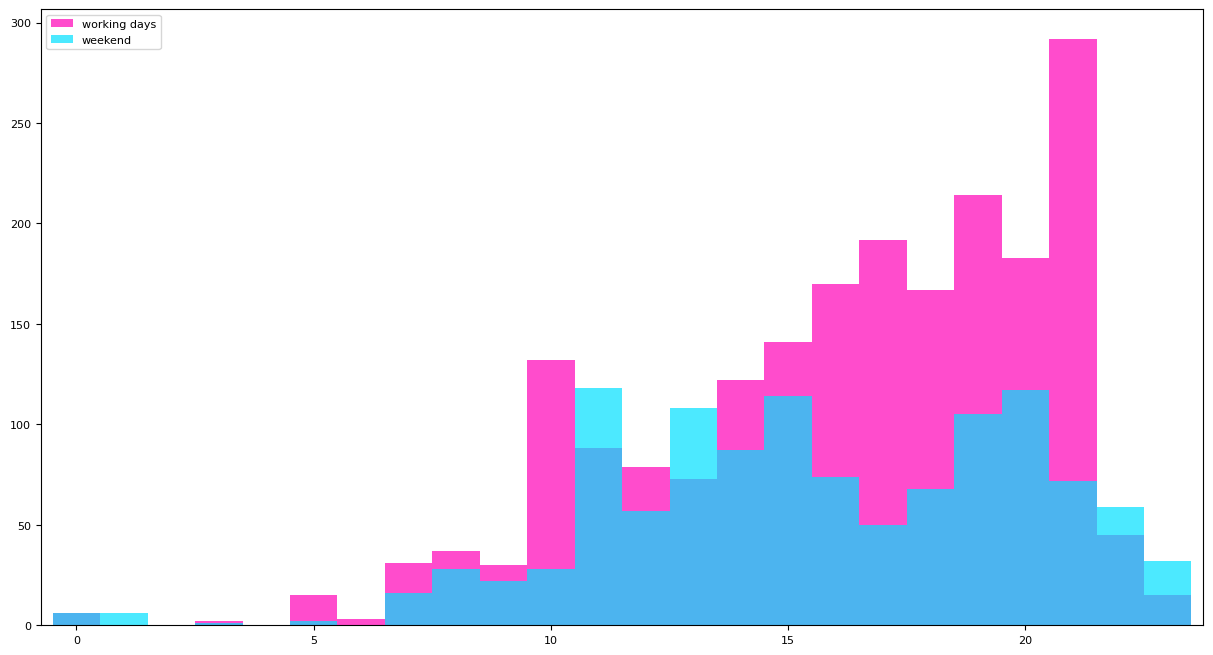

In [6]:
fig, ax = plt.subplots(figsize=(15, 8))
workdays.plot(
    x='hour',
    y='count',
    kind='bar', 
    fontsize=8,
    alpha=0.7,
    color="#FF00B7",
    width=1,
    label="working days",
    ax=ax
)
weekends.plot(
    x='hour',
    y='count',
    kind='bar', 
    fontsize=8,
    alpha=0.7,
    color="#00E1FF",
    width=1,
    label="weekend",
    ax=ax
)
ax.set_xlabel('', fontsize=8)
ax.set_ylabel('', fontsize=8)
ax.legend(loc='upper left', fontsize=8)
ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xticklabels(['0', '5', '10', '15', '20'], rotation=0)

plt.show()

## 6 Бывали ли часы, когда общее количество коммитов было выше в выходные дни, чем в рабочие дни?

In [7]:
merged_df = pd.merge(workdays, weekends, on='hour', suffixes=('_workday', '_weekend'))
exceeding_hours = merged_df.query('count_weekend > count_workday')['hour'].sort_values(ascending=False).head(4)
print("Четыре наиболее распространенных часа, когда активность на выходных выше:")
print(", ".join(map(str, exceeding_hours.values)))

Четыре наиболее распространенных часа, когда активность на выходных выше:
23, 22, 13, 11


## 7 Закроем соединение с базой данных.

In [8]:
conn.close()